# ROC Curves — Dead-End Detection

Loads `pre_flag_results.pkl` produced by `eval_rl.py` and computes ROC curves.

**Section 1 (debug):** Continuous IQN only — verify the model produces a meaningful signal before comparing with baselines.

**Section 2:** All models side-by-side (IQN+CQL, IQN Baseline, Continuous IQN).

Run `eval_rl.py` first:
```bash
~/miniforge3/envs/vf/bin/python3 eval_rl.py -c iqn_continuous_mimic
~/miniforge3/envs/vf/bin/python3 eval_rl.py -c iqn_cql          # discrete IQN+CQL
~/miniforge3/envs/vf/bin/python3 eval_rl.py -c iqn_baseline      # discrete IQN baseline
```

In [15]:
import os, sys, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sys.path.insert(0, os.path.abspath('..'))

METRICS_DIR = '../runs'
plt.rcParams.update({'font.size': 14})
# Standard color mapping for consistency
MODEL_COLORS = {"Continuous IQN": "#8856a7", "Continuous IQN (Ours)": "#8856a7", "IQN+CQL": "#2ca25f", "IQN Baseline": "#feb24c"}
MODEL_PALETTES = {"Continuous IQN": "Purples", "Continuous IQN (Ours)": "Purples", "IQN+CQL": "Greens", "IQN Baseline": "Oranges"}


## Helpers

All ROC logic is self-contained here so the notebook runs independently of `analysis_utils.py`.

In [16]:
thresh_array = np.linspace(0.0, 1.0, 1001, dtype=np.float32)
use_gpu = torch.cuda.is_available()
device  = torch.device('cuda' if use_gpu else 'cpu')
print('Device:', device)


def _stack_traj_values(series):
    """Stack a pandas Series of scalars or arrays into (T, n_alpha) float32."""
    first = series.iloc[0]
    if np.isscalar(first):
        return series.to_numpy(dtype=np.float32)[:, None]
    return np.vstack(list(series.values)).astype(np.float32)


def compute_flag_tensor(v_dn, v_rn, thresholds):
    """Vectorised flagging over all (timestep, threshold, alpha) combinations.

    Parameters
    ----------
    v_dn : (T, n_alpha)  — D-network signal, ∈ [-1, 0]
    v_rn : (T, n_alpha)  — R-network signal, ∈ [0, 1]
    thresholds : (n_thr,)

    Returns
    -------
    flags : (T, n_thr, n_alpha) bool
    """
    thresholds = thresholds.astype(np.float32)
    if use_gpu:
        vd  = torch.as_tensor(v_dn,       device=device)
        vr  = torch.as_tensor(v_rn,       device=device)
        thr = torch.as_tensor(thresholds, device=device)
        flags = (
            (vd[:, None, :] < (thr[None, :, None] - 1.0)) &
            (vr[:, None, :] <  thr[None, :, None])
        )
        return flags.cpu().numpy()
    return (
        (v_dn[:, None, :] < (thresholds[None, :, None] - 1.0)) &
        (v_rn[:, None, :] <  thresholds[None, :, None])
    )


def build_flag_arrays(results, thresholds):
    """Compute per-trajectory 'was ever flagged' arrays.

    Parameters
    ----------
    results : pre_flag_results dict from eval_rl.py
    thresholds : (n_thr,) array

    Returns
    -------
    ns_flags : (n_ns, n_thr, n_alpha) bool  — non-survivors
    s_flags  : (n_s,  n_thr, n_alpha) bool  — survivors
    n_alpha  : int
    """
    n_ns = len(results['nonsurvivors']['dn_q_selected_action_traj'])
    n_s  = len(results['survivors']['dn_q_selected_action_traj'])

    # Infer n_alpha from first trajectory
    sample = results['nonsurvivors']['dn_q_selected_action_traj'][0]
    n_alpha = sample.shape[-1] if sample.ndim > 1 else 1
    n_thr   = len(thresholds)

    ns_flags = np.zeros((n_ns, n_thr, n_alpha), dtype=bool)
    s_flags  = np.zeros((n_s,  n_thr, n_alpha), dtype=bool)

    for traj_idx, (arr_vdn, arr_vrn) in enumerate(
        zip(results['nonsurvivors']['dn_q_selected_action_traj'],
            results['nonsurvivors']['rn_q_selected_action_traj'])
    ):
        vdn = np.atleast_2d(np.asarray(arr_vdn, dtype=np.float32))
        vrn = np.atleast_2d(np.asarray(arr_vrn, dtype=np.float32))
        if vdn.ndim == 1: vdn = vdn[:, None]
        if vrn.ndim == 1: vrn = vrn[:, None]
        flags = compute_flag_tensor(vdn, vrn, thresholds)  # (T, n_thr, n_alpha)
        ns_flags[traj_idx] = np.any(flags, axis=0)

    for traj_idx, (arr_vdn, arr_vrn) in enumerate(
        zip(results['survivors']['dn_q_selected_action_traj'],
            results['survivors']['rn_q_selected_action_traj'])
    ):
        vdn = np.atleast_2d(np.asarray(arr_vdn, dtype=np.float32))
        vrn = np.atleast_2d(np.asarray(arr_vrn, dtype=np.float32))
        if vdn.ndim == 1: vdn = vdn[:, None]
        if vrn.ndim == 1: vrn = vrn[:, None]
        flags = compute_flag_tensor(vdn, vrn, thresholds)  # (T, n_thr, n_alpha)
        s_flags[traj_idx] = np.any(flags, axis=0)

    return ns_flags, s_flags, n_alpha


def compute_roc(results, thresholds=None):
    """Compute sorted FPR, TPR, and AUC for each alpha level.

    Returns
    -------
    fpr : (n_thr, n_alpha)
    tpr : (n_thr, n_alpha)
    auc : (n_alpha,)
    """
    if thresholds is None:
        thresholds = thresh_array

    ns_flags, s_flags, n_alpha = build_flag_arrays(results, thresholds)
    n_ns = ns_flags.shape[0]
    n_s  = s_flags.shape[0]

    tpr = ns_flags.sum(axis=0) / n_ns  # (n_thr, n_alpha)
    fpr = s_flags.sum(axis=0)  / n_s

    auc_vals = np.zeros(n_alpha)
    fpr_sorted = np.zeros_like(fpr)
    tpr_sorted = np.zeros_like(tpr)
    for ii in range(n_alpha):
        idx = np.argsort(fpr[:, ii])
        fpr_sorted[:, ii] = fpr[idx, ii]
        tpr_sorted[:, ii] = tpr[idx, ii]
        auc_vals[ii] = np.trapezoid(tpr_sorted[:, ii], fpr_sorted[:, ii])

    return fpr_sorted, tpr_sorted, auc_vals

Device: cuda


---
## Section 1 — Continuous IQN (debug)

Check that `pre_flag_results.pkl` from `eval_rl.py -c iqn_continuous_mimic` contains
a non-trivial signal before adding the discrete baselines.

In [17]:
with open(os.path.join(METRICS_DIR, 'iqn_continuous_mimic', 'pre_flag_results.pkl'), 'rb') as f:
    cont_results = pickle.load(f)

n_ns_cont = len(cont_results['nonsurvivors']['dn_q_selected_action_traj'])
n_s_cont  = len(cont_results['survivors']['dn_q_selected_action_traj'])
print(f'Non-survivors: {n_ns_cont}  |  Survivors: {n_s_cont}')

sample_vdn = cont_results['nonsurvivors']['dn_q_selected_action_traj'][0]
print(f'v_dn shape for first NS traj: {np.asarray(sample_vdn).shape}')
print(f'v_dn range: [{np.asarray(sample_vdn).min():.4f}, {np.asarray(sample_vdn).max():.4f}]')

Non-survivors: 180  |  Survivors: 1197
v_dn shape for first NS traj: (51, 20)
v_dn range: [-0.0503, 0.0000]


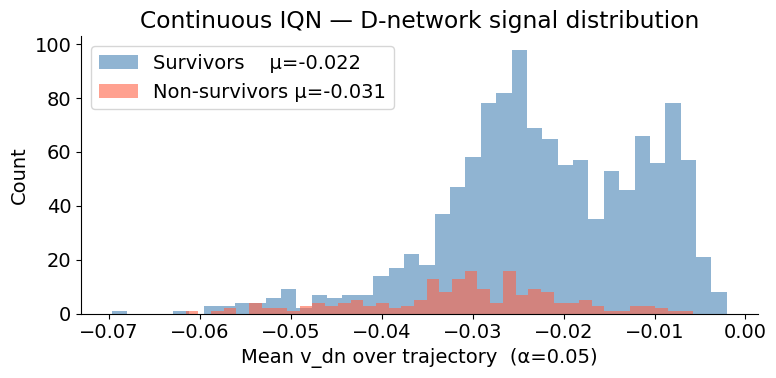

In [18]:
# Sanity check: per-trajectory mean v_dn at alpha index 0 (α=0.05)
# Non-survivors should have lower (more negative) v_dn than survivors.

alpha_idx = 0  # α=0.05 — most pessimistic CVaR

def traj_mean_vdn(results, group, alpha_idx=0):
    out = []
    for arr in results[group]['dn_q_selected_action_traj']:
        a = np.asarray(arr, dtype=np.float32)
        if a.ndim == 1:
            out.append(a.mean())
        else:
            out.append(a[:, alpha_idx].mean())
    return np.array(out)

ns_vdn = traj_mean_vdn(cont_results, 'nonsurvivors', alpha_idx)
s_vdn  = traj_mean_vdn(cont_results, 'survivors',    alpha_idx)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s_vdn,  bins=40, alpha=0.6, color='steelblue', label=f'Survivors    μ={s_vdn.mean():.3f}')
ax.hist(ns_vdn, bins=40, alpha=0.6, color='tomato',    label=f'Non-survivors μ={ns_vdn.mean():.3f}')
ax.set_xlabel('Mean v_dn over trajectory  (α=0.05)')
ax.set_ylabel('Count')
ax.set_title('Continuous IQN — D-network signal distribution')
ax.legend()
sns.despine(fig)
plt.tight_layout()
plt.show()

# If the two histograms overlap heavily the model has not separated the groups
# and AUC will be near 0.5. If NS has lower (more negative) v_dn the model works.

In [19]:
print('Computing ROC for Continuous IQN...')
fpr_cont, tpr_cont, auc_cont = compute_roc(cont_results)

VaR_labels = np.round(np.linspace(0.05, 1.0, num=20), 2)
n_alpha = fpr_cont.shape[1]
print(f'n_alpha={n_alpha}  |  AUC range: [{auc_cont.min():.4f}, {auc_cont.max():.4f}]')
print('AUC per α:', np.round(auc_cont, 4))

Computing ROC for Continuous IQN...
n_alpha=20  |  AUC range: [0.6133, 0.7114]
AUC per α: [0.7049 0.7084 0.7097 0.7096 0.7109 0.7114 0.7091 0.7066 0.7041 0.6986
 0.6954 0.6927 0.6839 0.6774 0.6697 0.6593 0.6478 0.6392 0.6278 0.6133]


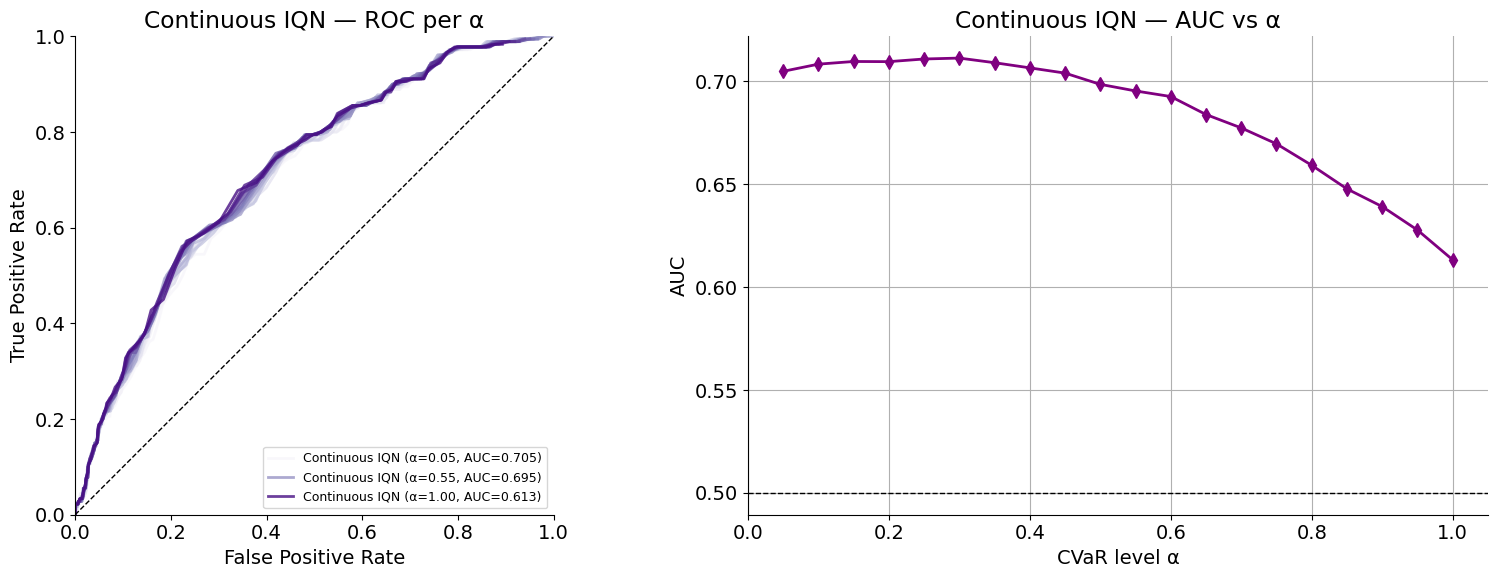

Best AUC: 0.7114 at α=0.30


In [20]:
palette_cont = sns.color_palette('Purples', n_colors=n_alpha)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: ROC curves
ax = axes[0]
for ii in range(n_alpha):
    ax.plot(fpr_cont[:, ii], tpr_cont[:, ii],
            color=palette_cont[ii], lw=2,
            label=f'Continuous IQN (α={VaR_labels[ii]:.2f}, AUC={auc_cont[ii]:.3f})' if ii in (0, n_alpha//2, n_alpha-1) else '',
            alpha=0.8)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Continuous IQN — ROC per α')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.legend(fontsize=9)
ax.set_aspect('equal')
sns.despine(ax=ax)

# Right: AUC vs α
ax2 = axes[1]
ax2.plot(VaR_labels[:n_alpha], auc_cont, 'd-', color='purple', lw=2, markersize=7)
ax2.axhline(0.5, color='k', linestyle='--', lw=1)
ax2.set_xlabel('CVaR level α')
ax2.set_ylabel('AUC')
ax2.set_title('Continuous IQN — AUC vs α')
ax2.set_xlim([0, 1.05])
ax2.grid(True)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(os.path.join(METRICS_DIR, 'iqn_continuous_mimic', 'roc_debug.png'), dpi=150)
plt.show()
print(f'Best AUC: {auc_cont.max():.4f} at α={VaR_labels[np.argmax(auc_cont)]:.2f}')

---
## Section 2 — All models

Load discrete IQN results and plot all three models together.
Skip this section if only the continuous model has been evaluated.

In [21]:
# Adjust these paths to match your checkpoint_fname values
IQN_CQL_PATH      = os.path.join(METRICS_DIR, 'IQN', 'paper', 'pre_flag_results.pkl')
IQN_BASE_PATH     = os.path.join(METRICS_DIR, 'IQNBaseline', 'paper', 'pre_flag_results.pkl')

def _try_load(path):
    if not os.path.exists(path):
        print(f'  [skipped] {path} not found')
        return None
    with open(path, 'rb') as f:
        data = pickle.load(f)
    n_ns = len(data['nonsurvivors']['dn_q_selected_action_traj'])
    n_s  = len(data['survivors']['dn_q_selected_action_traj'])
    print(f'  Loaded {path}  (NS={n_ns}, S={n_s})')
    return data

iqn_cql_results  = _try_load(IQN_CQL_PATH)
iqn_base_results = _try_load(IQN_BASE_PATH)

  Loaded ../runs/IQN/paper/pre_flag_results.pkl  (NS=209, S=1422)
  Loaded ../runs/IQNBaseline/paper/pre_flag_results.pkl  (NS=209, S=1422)


In [22]:
models = []
if iqn_cql_results  is not None: models.append(('IQN+CQL',       iqn_cql_results,  MODEL_PALETTES['IQN+CQL'],  '*'))
if iqn_base_results is not None: models.append(('IQN Baseline',   iqn_base_results, MODEL_PALETTES['IQN Baseline'], 's'))
models.append(('Continuous IQN', cont_results, MODEL_PALETTES['Continuous IQN'], 'd'))

roc_data = {}
for name, res, _, _ in models:
    print(f'Computing ROC for {name}...')
    fpr, tpr, auc = compute_roc(res)
    roc_data[name] = (fpr, tpr, auc)
    print(f'  AUC: min={auc.min():.4f}  mean={auc.mean():.4f}  max={auc.max():.4f}')

Computing ROC for IQN+CQL...
  AUC: min=0.7877  mean=0.8123  max=0.8187
Computing ROC for IQN Baseline...
  AUC: min=0.7941  mean=0.7987  max=0.8103
Computing ROC for Continuous IQN...
  AUC: min=0.6133  mean=0.6840  max=0.7114


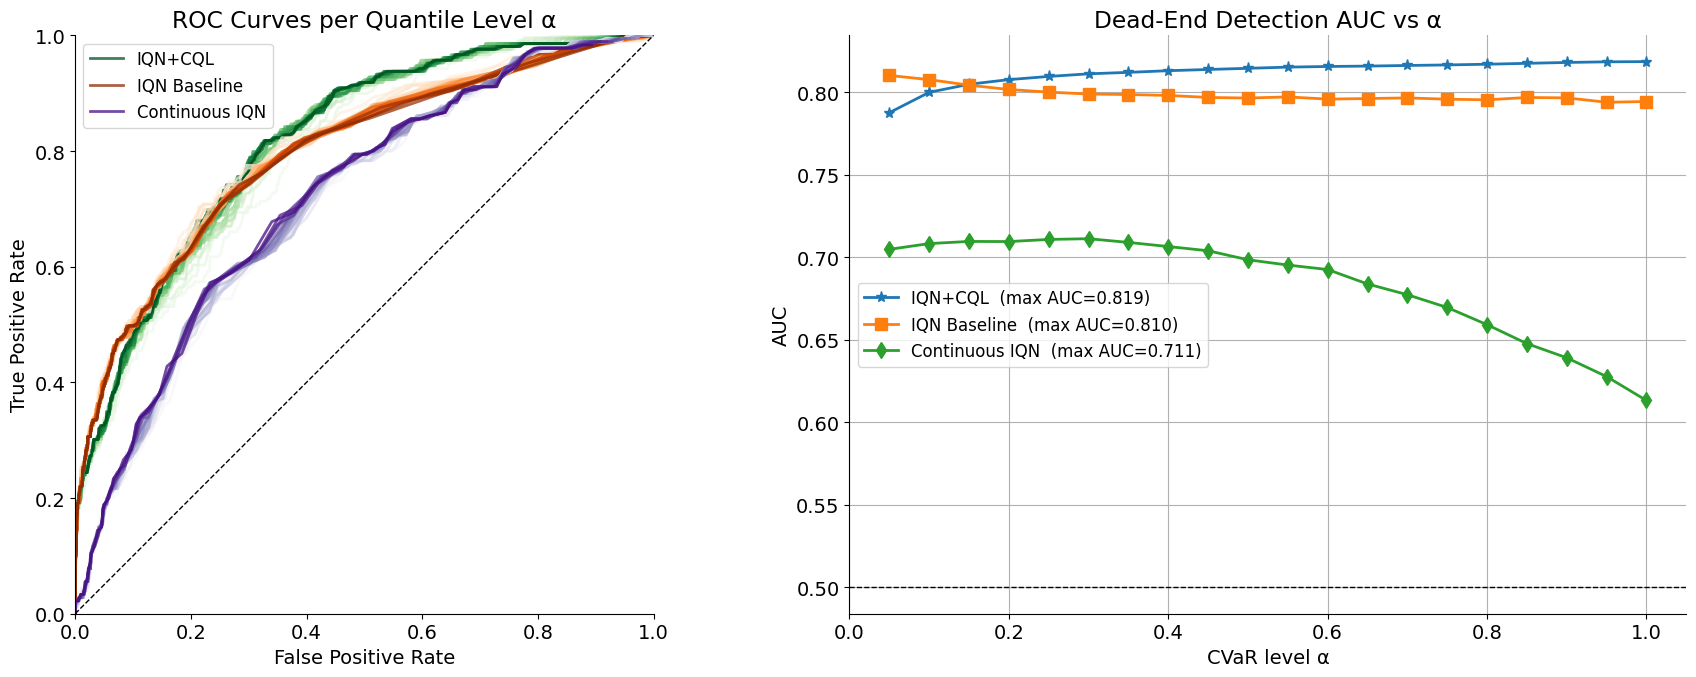

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax_roc = axes[0]
ax_auc = axes[1]

for name, res, pal, marker in models:
    fpr, tpr, auc = roc_data[name]
    n_a = fpr.shape[1]
    palette = sns.color_palette(pal, n_colors=n_a)
    for ii in range(n_a):
        ax_roc.plot(fpr[:, ii], tpr[:, ii],
                    color=palette[ii], lw=2,
                    label=name if ii == n_a - 1 else '',
                    alpha=0.75)
    ax_auc.plot(VaR_labels[:n_a], auc, f'{marker}-', color=MODEL_COLORS[name],
                lw=2, markersize=8, label=f'{name}  (max AUC={auc.max():.3f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves per Quantile Level α')
ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1])
ax_roc.legend(fontsize=12)
ax_roc.set_aspect('equal')
sns.despine(ax=ax_roc)

ax_auc.axhline(0.5, color='k', linestyle='--', lw=1)
ax_auc.set_xlabel('CVaR level α')
ax_auc.set_ylabel('AUC')
ax_auc.set_title('Dead-End Detection AUC vs α')
ax_auc.set_xlim([0, 1.05])
ax_auc.legend(fontsize=12)
ax_auc.grid(True)
sns.despine(ax=ax_auc)

plt.tight_layout()
plt.savefig(os.path.join(METRICS_DIR, 'roc_all_models.png'), dpi=150)
plt.show()

In [24]:
import pandas as pd

rows = []
for name, _, _, _ in models:
    _, _, auc = roc_data[name]
    rows.append({
        'Model':    name,
        'AUC min':  round(float(auc.min()),  4),
        'AUC mean': round(float(auc.mean()), 4),
        'AUC max':  round(float(auc.max()),  4),
        'Best α':   round(float(VaR_labels[np.argmax(auc)]), 2),
    })

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())

                AUC min  AUC mean  AUC max  Best α
Model                                             
IQN+CQL          0.7877    0.8123   0.8187    1.00
IQN Baseline     0.7941    0.7987   0.8103    0.05
Continuous IQN   0.6133    0.6840   0.7114    0.30


Computing optimal threshold per α for all models...


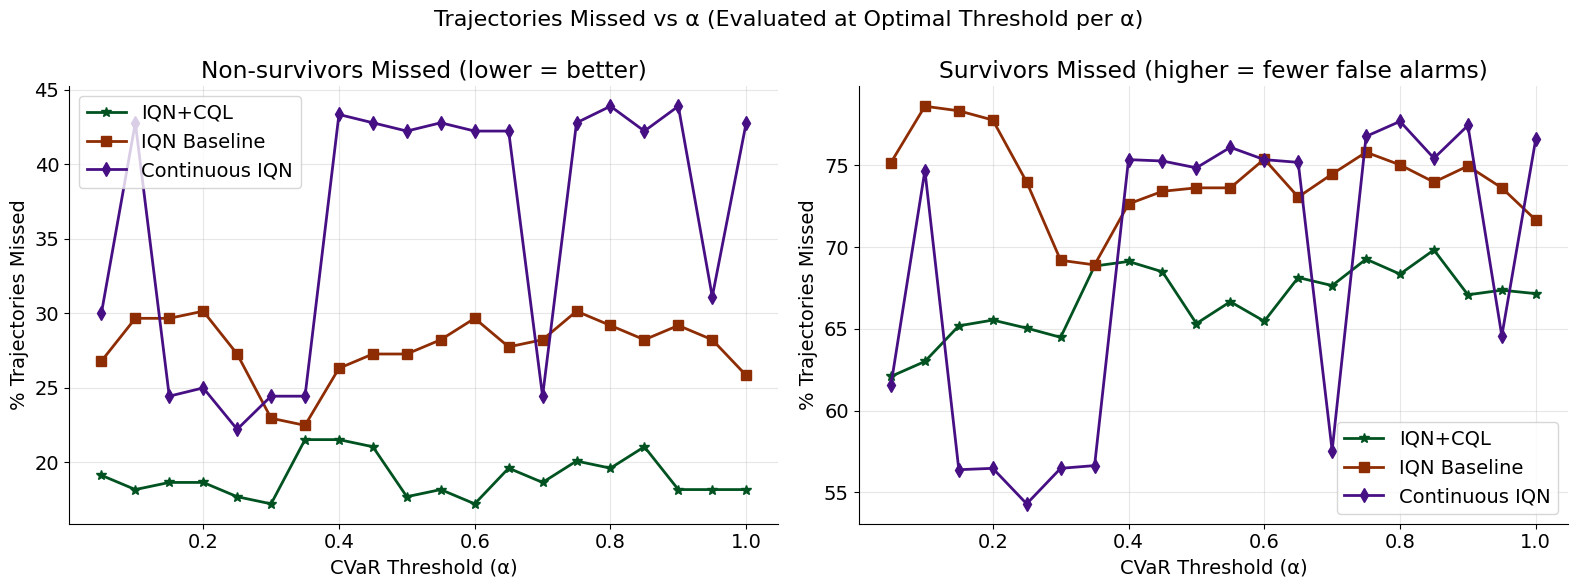

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Section 6: Missed Trajectories vs α (Optimal Threshold per α) ---

# We scan across 1001 possible thresholds to find the best one for each alpha
eval_thresholds = np.linspace(0.0, 1.0, 1001, dtype=np.float32)

records = []
print("Computing optimal threshold per α for all models...")

for name, res, pal, marker in models:
    # 1. Compute flags for all 1001 thresholds across all alphas
    ns_flags, s_flags, n_a = build_flag_arrays(res, eval_thresholds)
    n_ns = ns_flags.shape[0]
    n_s = s_flags.shape[0]
    
    # 2. Compute raw TPR and FPR (shape: 1001 thresholds, n_alpha)
    tpr_raw = ns_flags.sum(axis=0) / n_ns
    fpr_raw = s_flags.sum(axis=0) / n_s
    
    # 3. Find the best threshold for EACH alpha independently
    for alpha_idx in range(n_a):
        alpha_val = VaR_labels[alpha_idx]
        
        # Calculate Youden's J statistic (TPR - FPR) for all thresholds at this alpha
        j_scores = tpr_raw[:, alpha_idx] - fpr_raw[:, alpha_idx]
        
        # Get the index of the threshold that maximizes the score
        best_thr_idx = np.argmax(j_scores)
        
        # Extract the TPR and FPR at that optimal threshold
        opt_tpr = tpr_raw[best_thr_idx, alpha_idx]
        opt_fpr = fpr_raw[best_thr_idx, alpha_idx]
        
        # Convert to missed percentages
        missed_ns = (1.0 - opt_tpr) * 100
        missed_s = (1.0 - opt_fpr) * 100
        
        records.append({
            'Model': name,
            'Alpha': alpha_val,
            'Missed Non-survivors (%)': missed_ns,
            'Missed Survivors (%)': missed_s,
            'Palette': pal,
            'Marker': marker
        })

df_alpha_opt = pd.DataFrame(records)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Trajectories Missed vs α (Evaluated at Optimal Threshold per α)', fontsize=16)

# Group by model to draw the lines
for name, group in df_alpha_opt.groupby('Model', sort=False):
    pal = group['Palette'].iloc[0]
    marker = group['Marker'].iloc[0]
    
    # Use the darkest color from the model's assigned palette
    color = MODEL_COLORS[name]
    
    # Left plot: Non-survivors
    axes[0].plot(group['Alpha'], group['Missed Non-survivors (%)'], f'{marker}-', 
                 color=color, label=name, lw=2, markersize=7)
    # Right plot: Survivors
    axes[1].plot(group['Alpha'], group['Missed Survivors (%)'], f'{marker}-', 
                 color=color, label=name, lw=2, markersize=7)

# Format Left Plot (Non-survivors)
axes[0].set_title('Non-survivors Missed (lower = better)')
axes[0].set_xlabel('CVaR Threshold (α)')
axes[0].set_ylabel('% Trajectories Missed')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Format Right Plot (Survivors)
axes[1].set_title('Survivors Missed (higher = fewer false alarms)')
axes[1].set_xlabel('CVaR Threshold (α)')
axes[1].set_ylabel('% Trajectories Missed')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

sns.despine()
plt.tight_layout()

# Save and display
plt.savefig(os.path.join("./", 'comp_fig4_missed_trajs.png'), dpi=150)
plt.show()

Computing optimal threshold per α and calculating lead times for both groups...


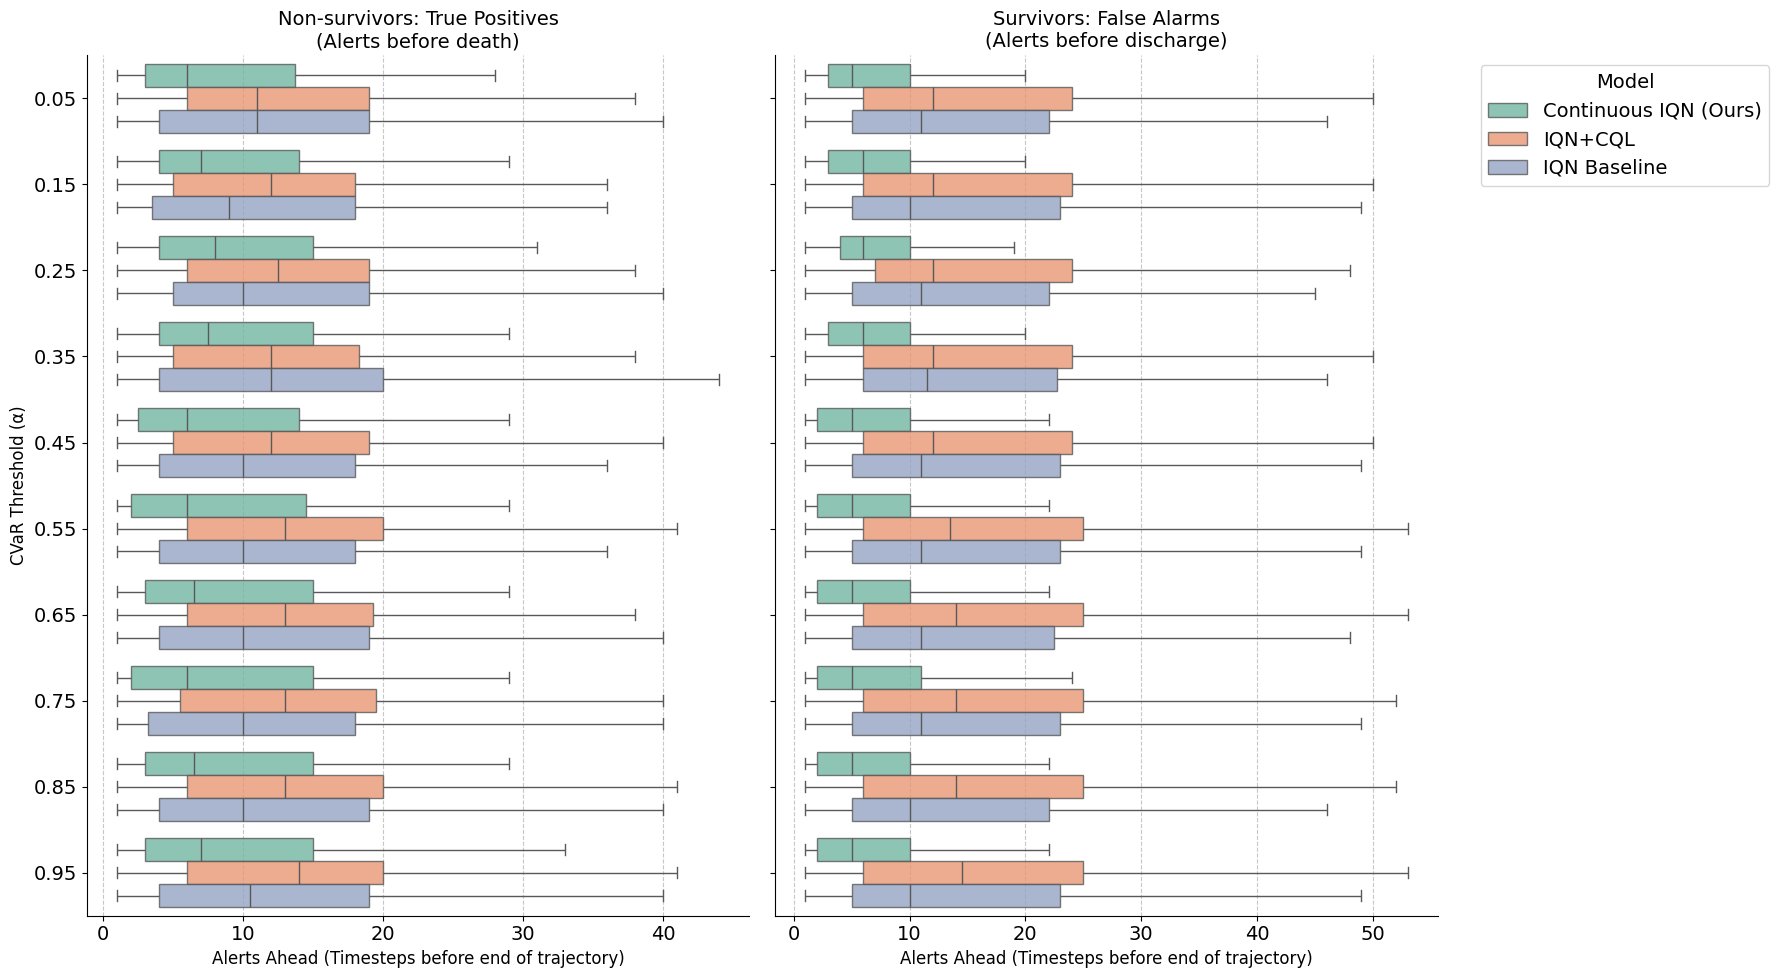

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# --- Section 8: Alerts Ahead Boxplots Split by Outcome (10 Alphas) ---

eval_thresholds = np.linspace(0.0, 1.0, 1001, dtype=np.float32)
records = []

# 1. Explicitly build the models list to GUARANTEE all models are included
explicit_models = []

cont_path = os.path.join(METRICS_DIR, 'iqn_continuous_mimic', 'pre_flag_results.pkl')
if os.path.exists(cont_path):
    with open(cont_path, 'rb') as f:
        explicit_models.append(('Continuous IQN (Ours)', pickle.load(f), MODEL_PALETTES['Continuous IQN (Ours)'], 'd'))

cql_path = os.path.join(METRICS_DIR, 'IQN', 'paper', 'pre_flag_results.pkl')
if os.path.exists(cql_path):
    with open(cql_path, 'rb') as f:
        explicit_models.append(('IQN+CQL', pickle.load(f), MODEL_PALETTES['IQN+CQL'], '*'))

base_path = os.path.join(METRICS_DIR, 'IQNBaseline', 'paper', 'pre_flag_results.pkl')
if os.path.exists(base_path):
    with open(base_path, 'rb') as f:
        explicit_models.append(('IQN Baseline', pickle.load(f), MODEL_PALETTES['IQN Baseline'], 's'))

# Pick 10 evenly spaced alpha indices out of the 20 available
alpha_indices_to_show = list(range(0, 20, 2))

print("Computing optimal threshold per α and calculating lead times for both groups...")

for name, res, pal, marker in explicit_models:
    # --- Step A: Find the optimal threshold index for each alpha ---
    ns_flags_ever, s_flags_ever, n_a = build_flag_arrays(res, eval_thresholds)
    n_ns = ns_flags_ever.shape[0]
    n_s = s_flags_ever.shape[0]
    
    tpr_raw = ns_flags_ever.sum(axis=0) / n_ns
    fpr_raw = s_flags_ever.sum(axis=0) / n_s
    
    best_thr_idx_per_alpha = []
    for alpha_idx in range(n_a):
        # Maximize Youden's J statistic
        j_scores = tpr_raw[:, alpha_idx] - fpr_raw[:, alpha_idx]
        best_thr_idx_per_alpha.append(np.argmax(j_scores))
        
    # --- Step B: Calculate lead times for NON-SURVIVORS (True Positives) ---
    for arr_vdn, arr_vrn in zip(
        res['nonsurvivors']['dn_q_selected_action_traj'],
        res['nonsurvivors']['rn_q_selected_action_traj']
    ):
        vdn = np.atleast_2d(np.asarray(arr_vdn, dtype=np.float32))
        vrn = np.atleast_2d(np.asarray(arr_vrn, dtype=np.float32))
        if vdn.ndim == 1: vdn = vdn[:, None]
        if vrn.ndim == 1: vrn = vrn[:, None]
        
        flags = compute_flag_tensor(vdn, vrn, eval_thresholds) 
        T = flags.shape[0]
        
        for alpha_idx in alpha_indices_to_show:
            opt_idx = best_thr_idx_per_alpha[alpha_idx]
            flag_seq = flags[:, opt_idx, alpha_idx]
            
            if np.any(flag_seq):
                first_flag_t = np.argmax(flag_seq)
                steps_ahead = T - first_flag_t
                records.append({
                    'Model': name, 'Alpha': f"{VaR_labels[alpha_idx]:.2f}", 
                    'Alerts Ahead': steps_ahead, 'Group': 'Non-survivors'
                })

    # --- Step C: Calculate lead times for SURVIVORS (False Alarms) ---
    for arr_vdn, arr_vrn in zip(
        res['survivors']['dn_q_selected_action_traj'],
        res['survivors']['rn_q_selected_action_traj']
    ):
        vdn = np.atleast_2d(np.asarray(arr_vdn, dtype=np.float32))
        vrn = np.atleast_2d(np.asarray(arr_vrn, dtype=np.float32))
        if vdn.ndim == 1: vdn = vdn[:, None]
        if vrn.ndim == 1: vrn = vrn[:, None]
        
        flags = compute_flag_tensor(vdn, vrn, eval_thresholds) 
        T = flags.shape[0]
        
        for alpha_idx in alpha_indices_to_show:
            opt_idx = best_thr_idx_per_alpha[alpha_idx]
            flag_seq = flags[:, opt_idx, alpha_idx]
            
            if np.any(flag_seq):
                first_flag_t = np.argmax(flag_seq)
                steps_ahead = T - first_flag_t
                records.append({
                    'Model': name, 'Alpha': f"{VaR_labels[alpha_idx]:.2f}", 
                    'Alerts Ahead': steps_ahead, 'Group': 'Survivors'
                })

df_lead_split = pd.DataFrame(records)

# --- Step D: Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)

# Left Plot: Non-survivors
sns.boxplot(
    data=df_lead_split[df_lead_split['Group'] == 'Non-survivors'],
    y='Alpha', x='Alerts Ahead', hue='Model',
    orient='h', palette=MODEL_COLORS, showfliers=False, boxprops=dict(alpha=0.8), ax=axes[0]
)
axes[0].set_title('Non-survivors: True Positives\n(Alerts before death)', fontsize=14)
axes[0].set_xlabel('Alerts Ahead (Timesteps before end of trajectory)', fontsize=12)
axes[0].set_ylabel('CVaR Threshold (α)', fontsize=12)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.7)
axes[0].get_legend().remove() # Remove legend to avoid clutter (it will be on the right plot)

# Right Plot: Survivors
sns.boxplot(
    data=df_lead_split[df_lead_split['Group'] == 'Survivors'],
    y='Alpha', x='Alerts Ahead', hue='Model',
    orient='h', palette=MODEL_COLORS, showfliers=False, boxprops=dict(alpha=0.8), ax=axes[1]
)
axes[1].set_title('Survivors: False Alarms\n(Alerts before discharge)', fontsize=14)
axes[1].set_xlabel('Alerts Ahead (Timesteps before end of trajectory)', fontsize=12)
axes[1].set_ylabel('') # Share the Y-axis label with the left plot
axes[1].grid(True, axis='x', linestyle='--', alpha=0.7)

# Move the unified legend outside the right plot
axes[1].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()

plt.savefig(os.path.join("./", 'hours_ahead.png'), dpi=150, bbox_inches='tight')
plt.show()